# SVM Gunshot Classifier — Training & Evaluation

This notebook loads the feature CSV generated by the trimming pipeline and:
2. Trains an **SVM (RBF kernel)** on the remaining data
3. Reports comprehensive evaluation metrics
4. Plots **Learning Curves** to diagnose overfitting/underfitting
5. Runs **Cross-Validation** for robust scoring
6. Saves a **Predictions CSV** with actual vs predicted labels

In [13]:
%pip install -q scikit-learn pandas numpy seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve, cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score,
    classification_report, confusion_matrix,
    log_loss, r2_score, roc_auc_score, roc_curve, matthews_corrcoef,
    precision_recall_curve,

)

SEED = 42
np.random.seed(SEED)
print(' All imports loaded.')

 All imports loaded.


## Step 1: Load the Dataset CSV

In [15]:
CSV_PATH = Path(r'c:\Desktop\Data-Cleaner\Data\Output\dataset_features_balanced.csv')  # BALANCED (duration bias removed))
OUTPUT_DIR = Path(r'c:\Desktop\Data-Cleaner\Data\Output')

df = pd.read_csv(CSV_PATH)
print(f' Dataset loaded: {len(df)} samples')
print(f'   Class 0 (non-gunshot): {(df["label"] == 0).sum()}')
print(f'   Class 1 (gunshot)    : {(df["label"] == 1).sum()}')
print(f'   Features             : {len([c for c in df.columns if c.startswith("mfcc_")])}')
df.head()

 Dataset loaded: 10368 samples
   Class 0 (non-gunshot): 6230
   Class 1 (gunshot)    : 4138
   Features             : 80


,file_path,trimmed_duration_ms,label,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,...,mfcc_70,mfcc_71,mfcc_72,mfcc_73,mfcc_74,mfcc_75,mfcc_76,mfcc_77,mfcc_78,mfcc_79
0,c:\Desktop\Data-Cleaner\Data\Output\trimmed_no...,487.62,0,-1031.08120,14.730996,0.777384,4.991124,1.355246,4.208106,1.801724,...,1.266447,2.441285,1.763805,1.432033,1.374517,1.770879,1.901176,1.550399,1.463553,1.891344
1,c:\Desktop\Data-Cleaner\Data\Output\trimmed_no...,371.52,0,-695.86237,-5.569222,1.328378,2.535788,2.279082,0.807535,-1.996518,...,1.472320,0.927157,1.196169,1.385303,1.440055,0.989268,1.064660,1.408114,1.563269,0.967351
2,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1346.76,1,-463.23624,40.241234,-1.549885,4.083778,5.473419,3.772687,5.041150,...,1.987796,1.775584,2.115471,1.761849,1.675900,1.604363,1.879056,1.810211,2.011548,2.046169
3,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1091.34,1,-534.51500,51.734290,-7.319930,0.332228,-0.028242,-1.549751,0.805324,...,2.411541,2.032710,1.793956,1.840461,1.664571,1.621786,1.771274,1.607353,2.111412,1.331406
4,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,603.72,1,-663.59204,20.655270,-2.227880,0.858566,0.547022,1.072816,0.106639,...,2.017970,1.313620,1.858664,1.063457,2.334037,1.503751,1.787006,1.021829,1.172709,1.220099


## Step 2: Balanced x/x Train-Test Split

In [16]:
TEST_PER_CLASS = 4000

df_0 = df[df['label'] == 0].copy()
df_1 = df[df['label'] == 1].copy()

test_0 = df_0.sample(n=TEST_PER_CLASS, random_state=SEED)
test_1 = df_1.sample(n=TEST_PER_CLASS, random_state=SEED)
test_df = pd.concat([test_0, test_1]).sample(frac=1, random_state=SEED)

train_df = df.drop(test_df.index).sample(frac=1, random_state=SEED)

feature_cols = [c for c in df.columns if c.startswith('mfcc_')]

X_train = train_df[feature_cols].values
y_train = train_df['label'].values
X_test  = test_df[feature_cols].values
y_test  = test_df['label'].values

print(f' Train set: {len(train_df)} samples  '
      f'(Class 0: {(y_train==0).sum()}, Class 1: {(y_train==1).sum()})')
print(f' Test  set: {len(test_df)} samples  '
      f'(Class 0: {(y_test==0).sum()}, Class 1: {(y_test==1).sum()})')

 Train set: 2368 samples  (Class 0: 2230, Class 1: 138)
 Test  set: 8000 samples  (Class 0: 4000, Class 1: 4000)


## Step 3: Feature Scaling

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print(' Features scaled with StandardScaler.')

 Features scaled with StandardScaler.


## Step 4:  Train SVM Model

In [18]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=SEED)
print(' Training SVM ...')
svm.fit(X_train, y_train)
print(' SVM training complete!')
print(f'   Kernel          : {svm.kernel}')
print(f'   C               : {svm.C}')
print(f'   Support Vectors : {svm.n_support_}')

 Training SVM ...
 SVM training complete!
   Kernel          : rbf
   C               : 1.0
   Support Vectors : [183 135]


## Step 5 Evaluation Metrics

In [19]:
y_proba = svm.predict_proba(X_test)
y_score = y_proba[:, 1]

# Tune threshold using out-of-fold training probabilities only (no test leakage).
cv_for_threshold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_train_proba = cross_val_predict(
    svm, X_train, y_train, cv=cv_for_threshold, method='predict_proba', n_jobs=1
)[:, 1]

prec_curve, rec_curve, pr_thresholds = precision_recall_curve(y_train, oof_train_proba)
f1_curve = (2 * prec_curve[:-1] * rec_curve[:-1]) / (prec_curve[:-1] + rec_curve[:-1] + 1e-12)

if len(pr_thresholds) == 0:
    best_threshold = 0.50
else:
    best_threshold = float(pr_thresholds[np.nanargmax(f1_curve)])

y_pred_default = (y_score >= 0.50).astype(int)
y_pred = (y_score >= best_threshold).astype(int)

acc      = accuracy_score(y_test, y_pred)
prec     = precision_score(y_test, y_pred)
rec      = recall_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred)
bal_acc  = balanced_accuracy_score(y_test, y_pred)
logloss  = log_loss(y_test, y_proba)
r2       = r2_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_score)
mcc      = matthews_corrcoef(y_test, y_pred)

baseline_prec = precision_score(y_test, y_pred_default)
baseline_rec  = recall_score(y_test, y_pred_default)
baseline_f1   = f1_score(y_test, y_pred_default)

metrics_df = pd.DataFrame({
    'Metric': [
        'Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1 Score',
        'Log Loss', 'R² Score', 'ROC-AUC', 'Matthews Corr. Coeff.'
    ],
    'Score': [acc, bal_acc, prec, rec, f1, logloss, r2, roc_auc, mcc]
})
metrics_df['Score'] = metrics_df['Score'].round(4)

print('\n Threshold tuning (from train CV only):')
print(f'   Best threshold (F1-optimal): {best_threshold:.4f}')
print(f'   Baseline @0.50 -> Precision: {baseline_prec:.4f}, Recall: {baseline_rec:.4f}, F1: {baseline_f1:.4f}')
print(f'   Tuned threshold -> Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}')

print('\n' + '='*50)
print('       SVM EVALUATION METRICS')
print('='*50)
for _, row in metrics_df.iterrows():
    icon = 'yes' if row['Metric'] not in ['Log Loss'] or row['Score'] < 0.5 else 'no'
    print(f'  {icon} {row["Metric"]:<25} {row["Score"]:>10.4f}')
print('='*50)
metrics_df


 Threshold tuning (from train CV only):
   Best threshold (F1-optimal): 0.2818
   Baseline @0.50 -> Precision: 0.9865, Recall: 0.7145, F1: 0.8288
   Tuned threshold -> Precision: 0.9777, Recall: 0.7897, F1: 0.8737

       SVM EVALUATION METRICS
  yes Accuracy                      0.8859
  yes Balanced Accuracy             0.8859
  yes Precision                     0.9777
  yes Recall                        0.7897
  yes F1 Score                      0.8737
  yes Log Loss                      0.3802
  yes R² Score                      0.5435
  yes ROC-AUC                       0.9759
  yes Matthews Corr. Coeff.         0.7864


,Metric,Score
0,Accuracy,0.8859
1,Balanced Accuracy,0.8859
2,Precision,0.9777
3,Recall,0.7897
4,F1 Score,0.8737
5,Log Loss,0.3802
6,R² Score,0.5435
7,ROC-AUC,0.9759
8,Matthews Corr. Coeff.,0.7864


In [20]:
print('\n Classification Report:\n')
print(classification_report(y_test, y_pred, target_names=['Non-Gunshot (0)', 'Gunshot (1)']))


 Classification Report:

                 precision    recall  f1-score   support

Non-Gunshot (0)       0.82      0.98      0.90      4000
    Gunshot (1)       0.98      0.79      0.87      4000

       accuracy                           0.89      8000
      macro avg       0.90      0.89      0.88      8000
   weighted avg       0.90      0.89      0.88      8000



## Step 6:  Confusion Matrix

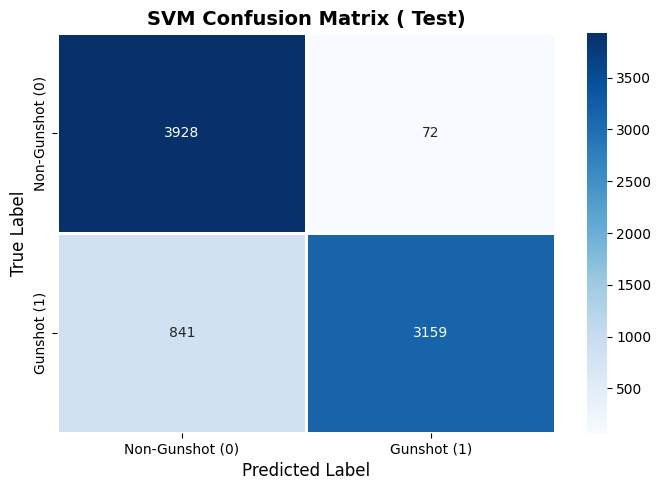

In [21]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Gunshot (0)', 'Gunshot (1)'],
            yticklabels=['Non-Gunshot (0)', 'Gunshot (1)'],
            linewidths=1, linecolor='white', ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('SVM Confusion Matrix ( Test)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7:  ROC Curve

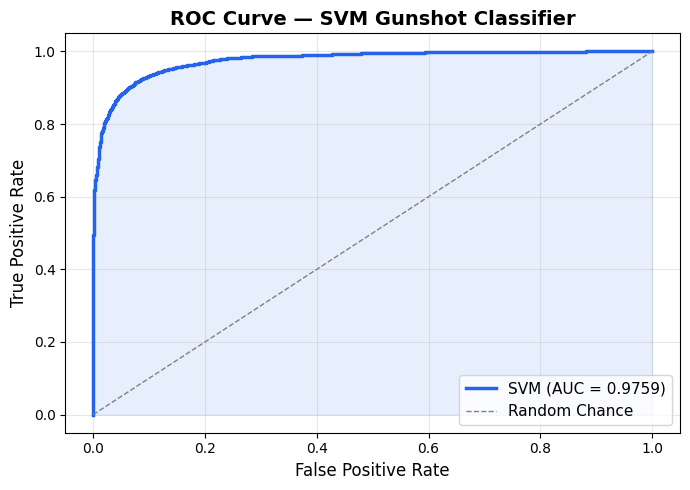

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#2563eb', lw=2.5, label=f'SVM (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Chance')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2563eb')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — SVM Gunshot Classifier', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8:  Metrics Bar Chart

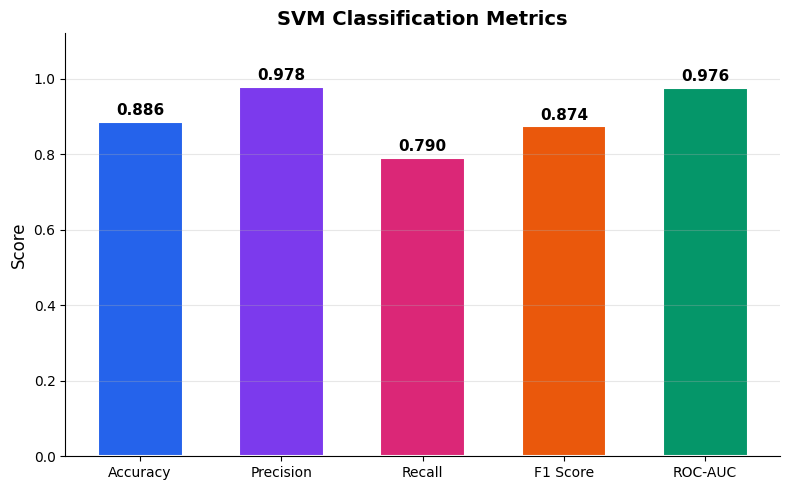

In [23]:
plot_metrics = metrics_df[metrics_df['Metric'].isin(
    ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
)].copy()
colors = ['#2563eb', '#7c3aed', '#db2777', '#ea580c', '#059669']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(plot_metrics['Metric'], plot_metrics['Score'],
              color=colors, edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, plot_metrics['Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('SVM Classification Metrics', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Step 9:  Learning Curves (Overfitting / Underfitting Diagnostic)

The learning curve plots **training accuracy vs validation accuracy** as the training set grows.
- If both converge at high accuracy → **good fit**
- If training is high but validation is low → **overfitting**
- If both are low → **underfitting**

 Computing learning curves (this may take a few minutes for SVM) ...


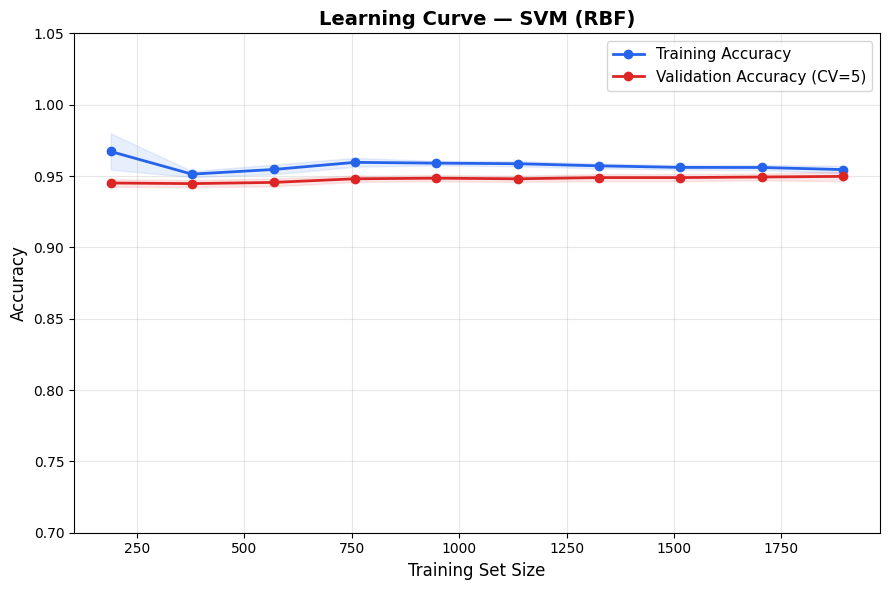


 Final gap (train - val): 0.0047
 Model appears well-fitted!


In [24]:
print(' Computing learning curves (this may take a few minutes for SVM) ...')

train_sizes, train_scores, val_scores = learning_curve(
    svm, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', n_jobs=1, random_state=SEED
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#2563eb', lw=2, label='Training Accuracy')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#2563eb')
ax.plot(train_sizes, val_mean, 'o-', color='#dc2626', lw=2, label='Validation Accuracy (CV=5)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='#dc2626')
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Learning Curve — SVM (RBF)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.7, 1.05)
plt.tight_layout()
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'\n Final gap (train - val): {gap:.4f}')
if gap > 0.05:
    print('  Potential OVERFITTING detected (gap > 5%)')
elif val_mean[-1] < 0.85:
    print('  Potential UNDERFITTING detected (val accuracy < 85%)')
else:
    print(' Model appears well-fitted!')

## Step 10:  Cross-Validation Scores

In [25]:
print(' Running 5-fold Stratified Cross-Validation ...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(svm, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=1)

print(f'\n Cross-Validation Results (5-Fold):')
for i, score in enumerate(cv_scores, 1):
    print(f'   Fold {i}: {score:.4f}')
print(f'\n   Mean Accuracy : {cv_scores.mean():.4f}')
print(f'   Std Deviation : {cv_scores.std():.4f}')

cv_f1 = cross_val_score(svm, X_train, y_train, cv=cv, scoring='f1', n_jobs=1)
print(f'\n   Mean F1 Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

 Running 5-fold Stratified Cross-Validation ...

 Cross-Validation Results (5-Fold):
   Fold 1: 0.9557
   Fold 2: 0.9451
   Fold 3: 0.9451
   Fold 4: 0.9493
   Fold 5: 0.9556

   Mean Accuracy : 0.9502
   Std Deviation : 0.0047

   Mean F1 Score : 0.2461 ± 0.1141


## Step 11:  Save Test Predictions CSV

Saves a CSV with `file_path`, `actual_label`, `predicted_label`, `predicted_proba_gunshot`.

In [26]:
predictions_df = test_df[['file_path', 'label']].copy()
predictions_df = predictions_df.rename(columns={'label': 'actual_label'})
predictions_df['predicted_label'] = y_pred
predictions_df['predicted_label_0_50'] = y_pred_default
predictions_df['decision_threshold'] = round(best_threshold, 4)
predictions_df['predicted_proba_gunshot'] = y_score.round(4)
predictions_df['correct'] = (predictions_df['actual_label'] == predictions_df['predicted_label'])
predictions_df['correct_0_50'] = (predictions_df['actual_label'] == predictions_df['predicted_label_0_50'])

pred_csv_path = OUTPUT_DIR / 'svm_test_predictions.csv'
predictions_df.to_csv(pred_csv_path, index=False)

n_correct = predictions_df['correct'].sum()
n_wrong   = (~predictions_df['correct']).sum()
n_correct_050 = predictions_df['correct_0_50'].sum()
n_wrong_050   = (~predictions_df['correct_0_50']).sum()

print(f' Predictions saved to: {pred_csv_path}')
print(f'   Threshold used      : {best_threshold:.4f}')
print(f'   Tuned correct       : {n_correct} / {len(predictions_df)}')
print(f'   Tuned incorrect     : {n_wrong} / {len(predictions_df)}')
print(f'   Baseline 0.50 right : {n_correct_050} / {len(predictions_df)}')
print(f'   Baseline 0.50 wrong : {n_wrong_050} / {len(predictions_df)}')

print(f'\n Misclassified samples with tuned threshold:')
misclassified = predictions_df[~predictions_df['correct']]
if len(misclassified) == 0:
    print('   None! Perfect predictions on test set.')
else:
    display(misclassified)

 Predictions saved to: c:\Desktop\Data-Cleaner\Data\Output\svm_test_predictions.csv
   Threshold used      : 0.2818
   Tuned correct       : 7087 / 8000
   Tuned incorrect     : 913 / 8000
   Baseline 0.50 right : 6819 / 8000
   Baseline 0.50 wrong : 1181 / 8000

 Misclassified samples with tuned threshold:


,file_path,actual_label,predicted_label,predicted_label_0_50,decision_threshold,predicted_proba_gunshot,correct,correct_0_50
1019,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.2818,0.2477,False,False
9178,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.2818,0.0811,False,False
1377,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.2818,0.0006,False,False
7284,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.2818,0.0659,False,False
2824,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.2818,0.0243,False,False
...,...,...,...,...,...,...,...,...
1463,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.2818,0.2602,False,False
604,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.2818,0.1383,False,False
4122,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.2818,0.1035,False,False
6245,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.2818,0.0615,False,False
